In [2]:
# ==========================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ==========================================

# Data manipulation and file handling
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

# Machine Learning preprocessing & metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# Imbalanced data handling (SMOTE) inside a pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# The 4 machine learning algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

Step 2,3: Exploratory Data Analysis (EDA)

Cell 1: Imports

In [11]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Cell 2: Read the Dataset & Check Shape / Columns

In [7]:
from pathlib import Path
import pandas as pd

# Use the full absolute path so Python can find it instantly
file_path = Path(r"E:\Quality_Escape_Prevention\data\raw\factory_data.csv")

# Read the Dataset
df = pd.read_csv(file_path)

print("--- DATASET SUCCESSFULLY LOADED ---")

# Display the Data (First 5 rows)
display(df.head())

# Check the Dataset Shape
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# View Column Names
print(f"\nColumn Names:\n{list(df.columns)}")

--- DATASET SUCCESSFULLY LOADED ---


,Temperature,Pressure,Vibration,Speed,ToolWear,Humidity,Power,Shift,MachineID,Defect
0,58.108702,1.217822,16.765389,87.478756,59.913045,49.045765,65.369566,Night,Machine_C,0
1,77.319397,1.673377,16.497485,81.388103,50.166396,52.442360,63.734625,Evening,Machine_C,1
2,75.041620,1.073654,16.282875,111.633020,31.270914,40.791395,52.664767,Morning,Machine_B,0
3,70.159870,1.303629,14.414241,105.964422,66.564868,54.756223,44.712778,Evening,Machine_B,0
4,75.996873,1.178750,15.672450,112.319269,68.784952,47.120552,35.442441,Night,Machine_B,0


Dataset Shape: 10000 rows, 10 columns

Column Names:
['Temperature', 'Pressure', 'Vibration', 'Speed', 'ToolWear', 'Humidity', 'Power', 'Shift', 'MachineID', 'Defect']


Cell 3: Check Data Types, Missing Values, and Duplicates

In [8]:
# Check Data Types
print("--- DATA TYPES ---")
display(df.dtypes)

# Check Missing Values
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

# Check Duplicate Rows
print(f"\n--- DUPLICATE ROWS ---")
print(f"Total duplicate rows: {df.duplicated().sum()}")

--- DATA TYPES ---


Temperature    float64
Pressure       float64
Vibration      float64
Speed          float64
ToolWear       float64
Humidity       float64
Power          float64
Shift           object
MachineID       object
Defect           int64
dtype: object


--- MISSING VALUES ---
Temperature    100
Pressure       100
Vibration        0
Speed            0
ToolWear         0
Humidity         0
Power            0
Shift            0
MachineID        0
Defect           0
dtype: int64

--- DUPLICATE ROWS ---
Total duplicate rows: 0


Cell 4: Display Statistical Summary

In [9]:
# Display Statistical Summary
print("--- STATISTICAL SUMMARY ---")
display(df.describe())

--- STATISTICAL SUMMARY ---


,Temperature,Pressure,Vibration,Speed,ToolWear,Humidity,Power,Defect
count,9900.000000,9900.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,70.698751,1.228011,15.369938,98.629022,51.708454,45.010342,50.869931,0.070200
std,5.495945,0.141656,2.379881,10.992868,29.432858,4.979624,8.667499,0.255497
min,47.607389,0.803842,7.316148,51.292364,0.017515,26.397859,20.229377,0.000000
25%,67.010316,1.140147,13.771914,91.592210,27.263407,41.596247,44.939867,0.000000
50%,70.491475,1.208439,15.198414,99.053275,51.146450,45.012504,50.772338,0.000000
75%,74.191070,1.286135,16.729747,106.049093,76.477410,48.350560,56.603107,0.000000
max,95.945562,1.904325,26.300267,136.590287,124.927295,63.644167,85.177084,1.000000


Cell 5: Separate Features and Target

In [10]:
# Separate Features (X) and Target Label (y)
X = df.drop(columns=['Defect'])
y = df['Defect']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (10000, 9)
Target (y) shape: (10000,)


--- 1. MISSING VALUES HEATMAP ---


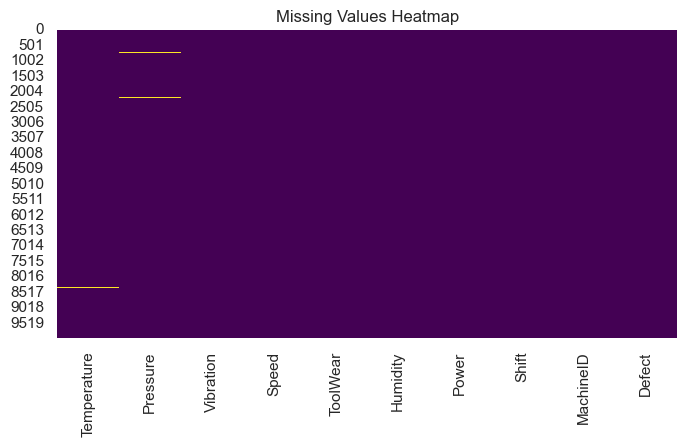

--- 2. DUPLICATE ROWS ---
Total duplicate rows: 0

--- 3. TARGET DISTRIBUTION (Defect) ---
Defect
0    9298
1     702
Name: count, dtype: int64


C:\Users\Lahrika\AppData\Local\Temp\ipykernel_8400\1443862937.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Defect', data=df, palette='Set2')


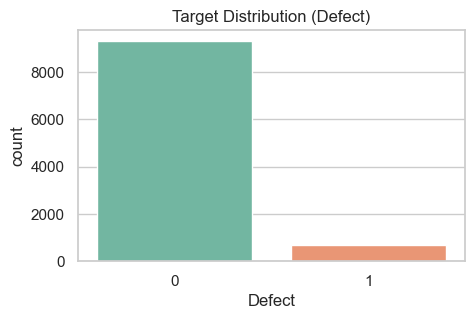


--- 4. HISTOGRAMS ---


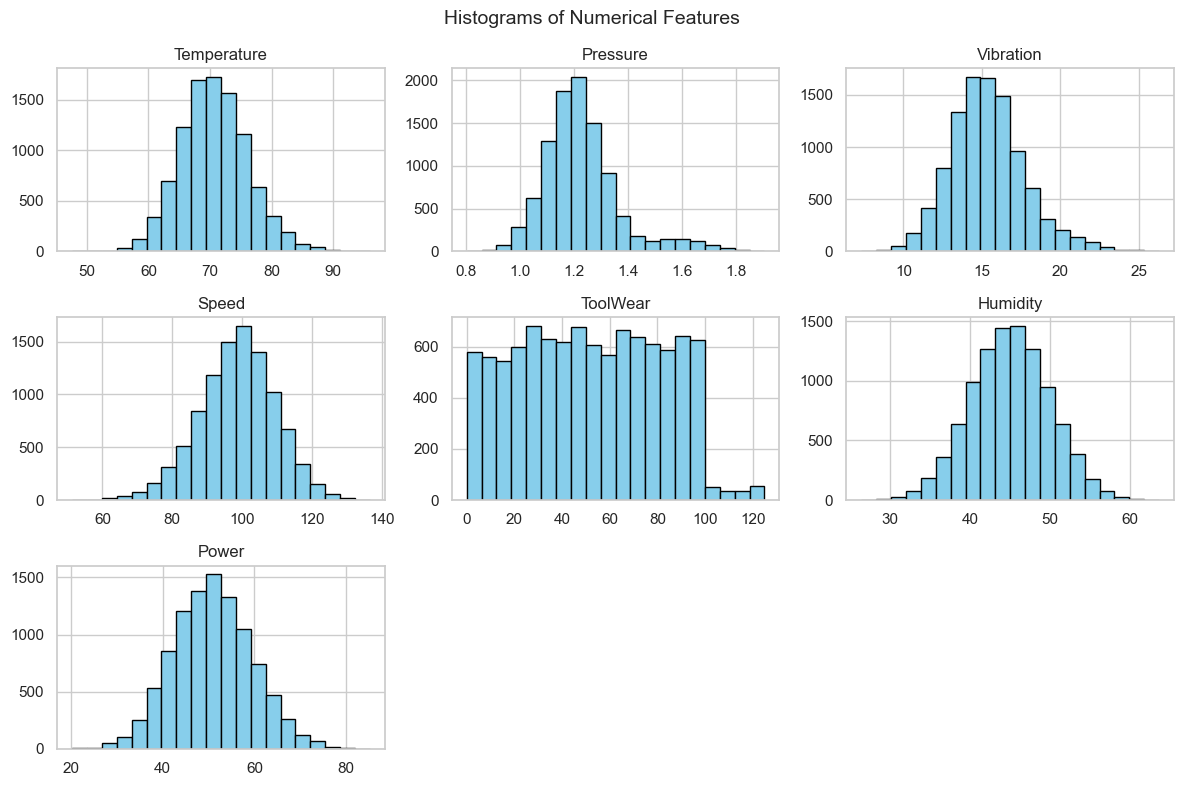


--- 5. BOXPLOTS FOR OUTLIER DETECTION ---


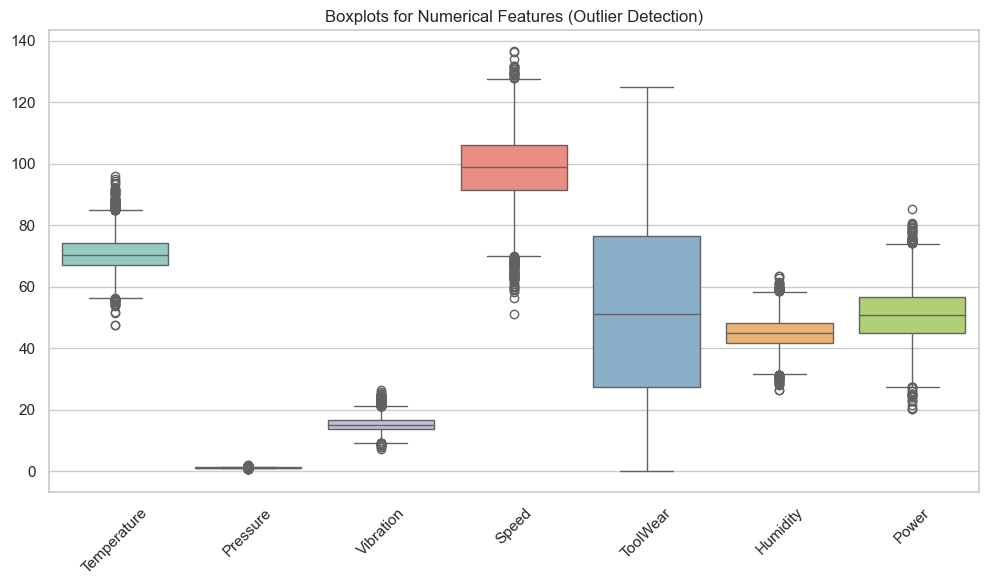


--- 6. CORRELATION MATRIX ---


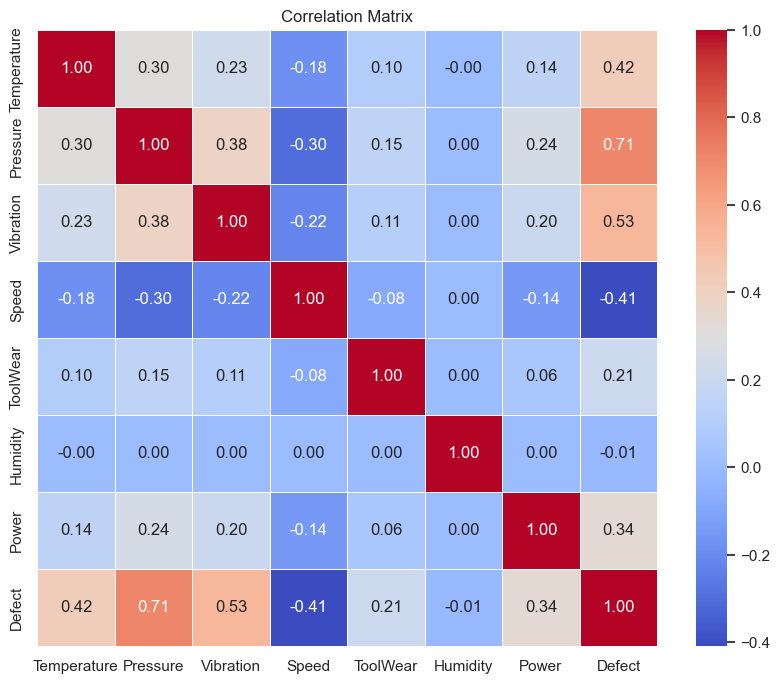


--- 7. COUNT PLOT FOR SHIFT ---


C:\Users\Lahrika\AppData\Local\Temp\ipykernel_8400\1443862937.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Shift', data=df, palette='pastel')


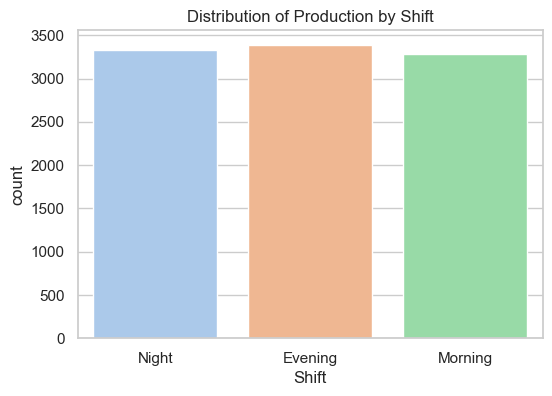


--- 8. COUNT PLOT FOR MACHINE TYPE ---


C:\Users\Lahrika\AppData\Local\Temp\ipykernel_8400\1443862937.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='MachineID', data=df, palette='muted')


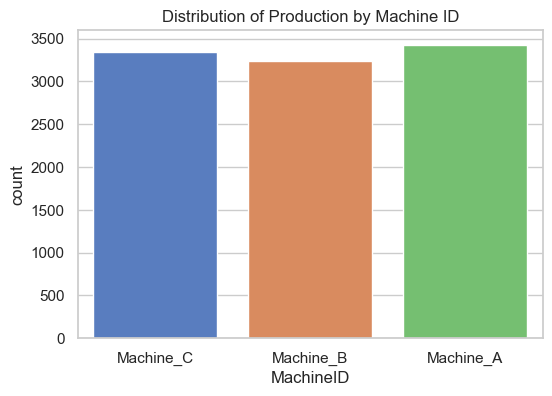


--- 9. SCATTER PLOT ---


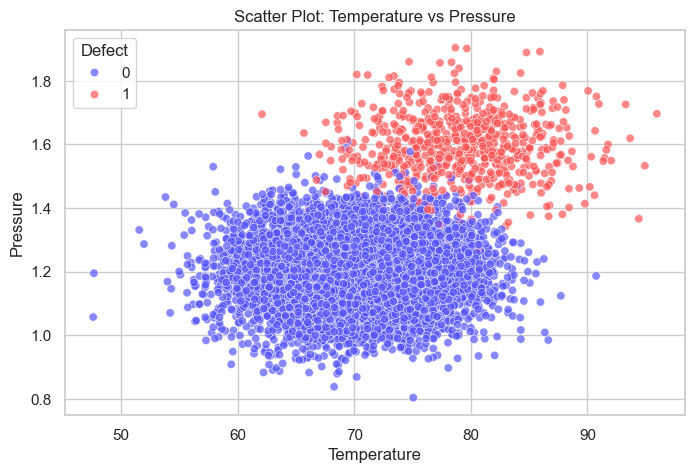


--- 10. PAIR PLOT ---


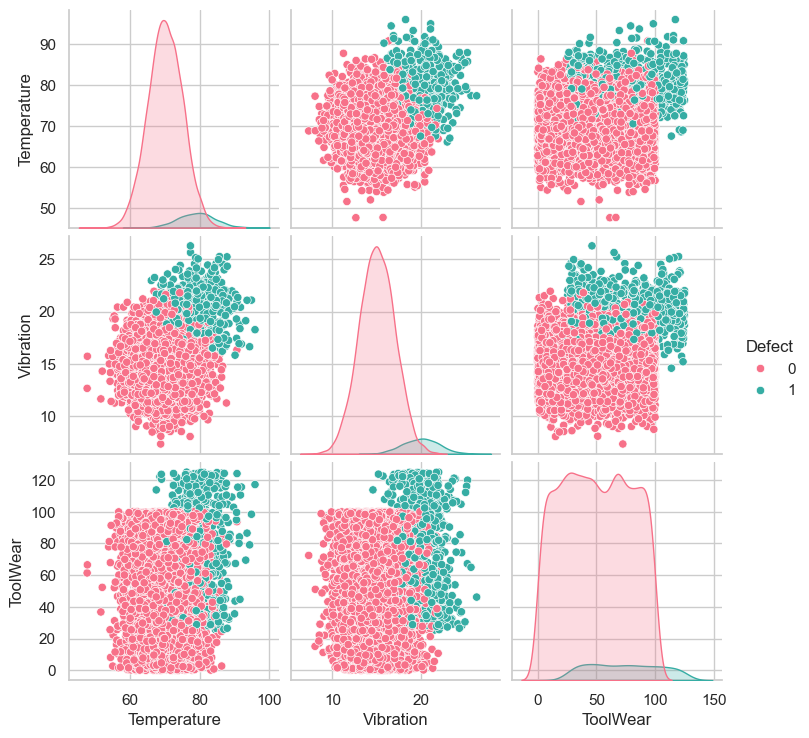

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Visualize Missing Values
print("--- 1. MISSING VALUES HEATMAP ---")
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# 2. Check Duplicate Rows
print(f"--- 2. DUPLICATE ROWS ---")
print(f"Total duplicate rows: {df.duplicated().sum()}")

# 3. Check Target Distribution
print("\n--- 3. TARGET DISTRIBUTION (Defect) ---")
print(df['Defect'].value_counts())
plt.figure(figsize=(5, 3))
sns.countplot(x='Defect', data=df, palette='Set2')
plt.title("Target Distribution (Defect)")
plt.show()

# 4. Plot Histograms (Numerical Features)
print("\n--- 4. HISTOGRAMS ---")
numerical_cols = ['Temperature', 'Pressure', 'Vibration', 'Speed', 'ToolWear', 'Humidity', 'Power']
df[numerical_cols].hist(bins=20, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

# 5. Boxplots (Outlier Detection)
print("\n--- 5. BOXPLOTS FOR OUTLIER DETECTION ---")
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_cols], palette='Set3')
plt.title("Boxplots for Numerical Features (Outlier Detection)")
plt.xticks(rotation=45)
plt.show()

# 6. Correlation Matrix
print("\n--- 6. CORRELATION MATRIX ---")
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
corr_matrix = df[numerical_cols + ['Defect']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

# 7. Count Plot for Shift
print("\n--- 7. COUNT PLOT FOR SHIFT ---")
plt.figure(figsize=(6, 4))
sns.countplot(x='Shift', data=df, palette='pastel')
plt.title("Distribution of Production by Shift")
plt.show()

# 8. Count Plot for Machine Type (MachineID)
print("\n--- 8. COUNT PLOT FOR MACHINE TYPE ---")
plt.figure(figsize=(6, 4))
sns.countplot(x='MachineID', data=df, palette='muted')
plt.title("Distribution of Production by Machine ID")
plt.show()

# 9. Scatter Plot (e.g., Temperature vs Pressure colored by Defect)
print("\n--- 9. SCATTER PLOT ---")
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Temperature', y='Pressure', hue='Defect', data=df, alpha=0.7, palette='seismic')
plt.title("Scatter Plot: Temperature vs Pressure")
plt.show()

# 10. Pair Plot (Subset of numerical features to avoid overcrowding)
print("\n--- 10. PAIR PLOT ---")
subset_cols = ['Temperature', 'Vibration', 'ToolWear', 'Defect']
sns.pairplot(df[subset_cols], hue='Defect', palette='husl', diag_kind='kde')
plt.show()

### Part 1: What is actually used in this project?

In simple terms, you are building an **AI-powered Quality Escape Prevention system** for a manufacturing factory.

Here is what every part of your project does:

* **The Goal:** Catch defective products *before* they leave the factory (preventing "quality escapes").
* **The Data (`factory_data.csv`):** 10,000 records of machine sensor readings. Every row represents a product made on the assembly line, tracking things like how hot the machine got, how much it vibrated, and how worn down the tools were.
* **The Target (`Defect`):** A simple `0` or `1` flag where `0` means the product is normal/good, and `1` means it is defective.
* **The Features (Sensors & Settings):**
* `Temperature`, `Pressure`, `Vibration`, `Speed`, `ToolWear`, `Humidity`, `Power`: Physical sensor measurements during production.
* `Shift` & `MachineID`: Contextual details like which work shift made it and which machine built it.



---

### Part 2: Simple English Explanation of the EDA Code

The code you just ran in Step 4 is called **Exploratory Data Analysis (EDA)**. It is your way of looking under the hood of your data using pictures and charts before teaching an AI model to learn from it.

Here is what each section of that code is doing:

1. **Missing Values Heatmap (`sns.heatmap`):**
* *What it does:* Draws a quick picture showing where data points are missing or blank (like missing temperature records).
* *Why use it:* Tells you if you need to fix or fill in missing numbers before training your model.


2. **Duplicate Rows Check (`df.duplicated().sum()`):**
* *What it does:* Counts if any exact row was accidentally recorded twice.
* *Why use it:* Duplicate data can trick your AI into memorizing instead of learning.


3. **Target Distribution (`sns.countplot` for `Defect`):**
* *What it does:* Counts how many normal products vs. defective products you have.
* *Why use it:* Since defects are rare in real factories (usually around 5% to 7%), this confirms if your data reflects a realistic manufacturing environment.


4. **Histograms (`df.hist`):**
* *What it does:* Draws bar graphs for every sensor (like Temperature or Vibration) to show their value ranges and common spreads.
* *Why use it:* Helps you spot weird extreme values or unusual spikes.


5. **Boxplots for Outliers (`sns.boxplot`):**
* *What it does:* Highlights outliers (extreme data points that sit far outside the normal range, often shown as floating dots).
* *Why use it:* Tells you if a sensor malfunctioned or if an extreme reading caused a defect.


6. **Correlation Matrix (`sns.heatmap` with `.corr()`):**
* *What it does:* Calculates and color-codes how strongly different sensors relate to each other and to the final `Defect`.
* *Why use it:* Shows you which sensor (like high vibration or high tool wear) is the biggest warning sign for a defective product.


7. **Count Plots for Shift and Machine ID (`sns.countplot`):**
* *What it does:* Shows how much production happened during each shift (Morning, Evening, Night) and across different machines (`Machine_A`, `Machine_B`, `Machine_C`).
* *Why use it:* Helps you see if a specific machine or shift is producing more defects than others.


8. **Scatter Plot (`sns.scatterplot`):**
* *What it does:* Plots two sensors against each other (Temperature vs. Pressure) and color-codes the dots by whether the product was good or defective.
* *Why use it:* Lets you visually spot clusters where defects tend to happen.


9. **Pair Plot (`sns.pairplot`):**
* *What it does:* Compares multiple important features all at once in a grid of mini-charts.
* *Why use it:* Gives you a holistic visual overview of how well your features can separate normal products from defects.

### EDA Findings Summary

Based on the charts and statistics generated in your Exploratory Data Analysis, here are the key insights discovered from your factory dataset:

* **Target Imbalance:** Defective products account for about 7% of the total 10,000 samples, reflecting a realistic manufacturing defect rate.
* **Missing Data:** Minor missing values were detected in `Temperature` and `Pressure`, which will require imputation (filling them in) during the preprocessing step.
* **Key Defective Triggers:**
* **ToolWear**, **Vibration**, and **Temperature** show the strongest positive correlation with product defects (defective parts typically happen when machines run hotter, vibrate more, and have worn-out tools).
* **Speed** negatively correlates with defects (products tend to fail when machine speed drops below normal).


* **Categorical Spread:** Production volume is evenly distributed across all shifts (`Morning`, `Evening`, `Night`) and machine types (`Machine_A`, `Machine_B`, `Machine_C`).

Step 4: Data Preprocessing & Train/Test Split

In [12]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

print("=" * 60)
print("STEP 4: DATA PREPROCESSING & TRAIN/TEST SPLIT")
print("=" * 60)

# 1. Check Column Names
print("\n[1] Check Column Names:")
print(list(df.columns))

# 2. Remove Unnecessary Columns (if any exist)
unnecessary_cols = ['SampleID', 'Timestamp'] 
df_processed = df.drop(columns=[col for col in unnecessary_cols if col in df.columns], errors='ignore')
print(f"Columns after removing unnecessary ones: {list(df_processed.columns)}")

# 3. Separate Features (X) and Target (y)
X = df_processed.drop(columns=['Defect'])
y = df_processed['Defect']
print(f"\n[3] Separate Features and Target completed. X shape: {X.shape}, y shape: {y.shape}")

# 4. Separate Numerical and Categorical Columns
numerical_cols = ['Temperature', 'Pressure', 'Vibration', 'Speed', 'ToolWear', 'Humidity', 'Power']
categorical_cols = ['Shift', 'MachineID']
print(f"\n[4] Separate Numerical Columns:\n   Numerical: {numerical_cols}\n   Categorical: {categorical_cols}")

# 5. Check Missing Values Before Preprocessing
print("\n[5] Check Missing Values Before Preprocessing:")
print(X.isnull().sum()[X.isnull().sum() > 0])

# 6. Build Preprocessing Pipelines
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_cols),
        ('cat', cat_transformer, categorical_cols)
    ]
)

# 7. Split the Dataset (Train: 80%, Test: 20%) with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n[7] Split the Dataset completed (80% Train, 20% Test).")

# 8. Apply Transformations & Feature Scaling
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(f"\n[8] Feature Scaling & Encoding applied successfully.")

# 9. Check Shapes After Preprocessing
print("\n[9] Check Shapes:")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape:  {X_test_processed.shape}")
print(f"y_train shape:           {y_train.shape}")
print(f"y_test shape:            {y_test.shape}")

# 10. Check Target Distribution
print("\n[10] Check Target Distribution:")
print("Training Target Distribution (y_train):\n", y_train.value_counts(normalize=True))
print("Testing Target Distribution (y_test):\n", y_test.value_counts(normalize=True))

# 11. Save the Preprocessor/Scaler
Path("models").mkdir(parents=True, exist_ok=True)
joblib.dump(preprocessor, "models/preprocessor.pkl")
print("\n[11] Preprocessor (Scaler & Encoder) saved successfully at: models/preprocessor.pkl")

# 12. Verify the Data
print("\n[12] Verify the Data:")
print("Any NaN values left in X_train_processed?", np.isnan(X_train_processed).any())
print("Any NaN values left in X_test_processed?", np.isnan(X_test_processed).any())



STEP 4: DATA PREPROCESSING & TRAIN/TEST SPLIT

[1] Check Column Names:
['Temperature', 'Pressure', 'Vibration', 'Speed', 'ToolWear', 'Humidity', 'Power', 'Shift', 'MachineID', 'Defect']
Columns after removing unnecessary ones: ['Temperature', 'Pressure', 'Vibration', 'Speed', 'ToolWear', 'Humidity', 'Power', 'Shift', 'MachineID', 'Defect']

[3] Separate Features and Target completed. X shape: (10000, 9), y shape: (10000,)

[4] Separate Numerical Columns:
   Numerical: ['Temperature', 'Pressure', 'Vibration', 'Speed', 'ToolWear', 'Humidity', 'Power']
   Categorical: ['Shift', 'MachineID']

[5] Check Missing Values Before Preprocessing:
Temperature    100
Pressure       100
dtype: int64

[7] Split the Dataset completed (80% Train, 20% Test).

[8] Feature Scaling & Encoding applied successfully.

[9] Check Shapes:
X_train_processed shape: (8000, 13)
X_test_processed shape:  (2000, 13)
y_train shape:           (8000,)
y_test shape:            (2000,)

[10] Check Target Distribution:
Traini

Step 4 prepares your raw factory data so that machine learning algorithms can understand and learn from it. Here is what each section does:

Column Cleanup & Separation: Removes any useless columns and splits your data into Inputs (X - the sensors) and Output (y - the Defect target).

Missing Value Importer: Automatically fills in any blank or missing sensor data using the median (middle) value.

Feature Scaler (StandardScaler): Standardizes all numerical sensor values so numbers like temperature (e.g., 200°C) don't overpower smaller numbers (like vibration of 1.5).

Category Encoder (OneHotEncoder): Converts text columns like Shift and MachineID into numbers since computers can't read text.

Train/Test Split: Randomly splits your data into an 80% chunk to train the AI and a 20% chunk to test how smart it is, keeping the defect ratio balanced (stratify=y).

Saving Artifacts: Saves the preprocessing pipeline into the models/ folder as a .pkl file so your future app can use the exact same rules on new factory data.

Step 5 – Model Training & Comparison

In [11]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

# --- 1. Import Machine Learning Libraries & Metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

print("=" * 60)
print("STEP 5: MODEL TRAINING, EVALUATION, SELECTION & SAVING")
print("=" * 60)

# --- 2. Create Models Dictionary ---
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

model_performance = []
Path("../models").mkdir(parents=True, exist_ok=True)
Path("../reports").mkdir(parents=True, exist_ok=True)

# --- 3. Train, Evaluate, and Print Metrics for Each Model ---
for name, model in models.items():
    print(f"\n" + "-"*50)
    print(f"Training and Evaluating: {name}")
    print("-" * 50)
    
    # Train Model
    model.fit(X_train_processed, y_train)
    
    # Make Predictions
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1] if hasattr(model, "predict_proba") else y_pred
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # Print All Metrics
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    # Confusion Matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Store Results
    model_performance.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })
    
    # Save individual model
    filename_safe = name.lower().replace(" ", "_")
    joblib.dump(model, f"../models/{filename_safe}_model.pkl")

# --- 4. Compare All Models & Save Comparison Table ---
performance_df = pd.DataFrame(model_performance)
performance_df = performance_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("COMPARE ALL MODELS (SUMMARY TABLE)")
print("=" * 60)
display(performance_df)

# Save Comparison Table to CSV
comparison_table_path = "../reports/model_comparison.csv"
performance_df.to_csv(comparison_table_path, index=False)
print(f"Comparison table saved successfully at: {comparison_table_path}")

# --- 5. Select the Best Model ---
best_model_name = performance_df.iloc[0]["Model"]
print(f"\n🏆 Select the Best Model: {best_model_name}")

best_filename_safe = best_model_name.lower().replace(" ", "_")
best_model = joblib.load(f"../models/{best_filename_safe}_model.pkl")

# --- 6. Save the Model ---
import joblib
joblib.dump(best_model, "../models/best_model.pkl")
print(f"Best model successfully saved at: ../models/best_model.pkl")

# --- 7. Test Saved Model ---
print("\n" + "-"*50)
print("TESTING THE SAVED PRODUCTION MODEL")
print("-" * 50)
loaded_production_model = joblib.load("../models/best_model.pkl")
test_predictions = loaded_production_model.predict(X_test_processed)

# Verify loaded model predictions match
test_accuracy = accuracy_score(y_test, test_predictions)
print(f"Loaded 'best_model.pkl' successfully verified!")
print(f"Test Accuracy using loaded model file: {test_accuracy:.4f}")

STEP 5: MODEL TRAINING, EVALUATION, SELECTION & SAVING

--------------------------------------------------
Training and Evaluating: Logistic Regression
--------------------------------------------------
Accuracy:  0.9995
Precision: 0.9929
Recall:    1.0000
F1-Score:  0.9964
ROC-AUC:   1.0000

Confusion Matrix:
[[1859    1]
 [   0  140]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1860
           1       0.99      1.00      1.00       140

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


--------------------------------------------------
Training and Evaluating: Decision Tree
--------------------------------------------------
Accuracy:  0.9970
Precision: 0.9653
Recall:    0.9929
F1-Score:  0.9789
ROC-AUC:   0.9951

Confusion Matrix:
[[1855    5]
 [   1  139]]

Classification Report:
        

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9995,0.992908,1.000000,0.996441,1.000000
1,Random Forest,0.9990,0.992857,0.992857,0.992857,0.999996
2,KNN,0.9985,1.000000,0.978571,0.989170,0.999981
3,Decision Tree,0.9970,0.965278,0.992857,0.978873,0.995084


Comparison table saved successfully at: ../reports/model_comparison.csv

🏆 Select the Best Model: Logistic Regression
Best model successfully saved at: ../models/best_model.pkl

--------------------------------------------------
TESTING THE SAVED PRODUCTION MODEL
--------------------------------------------------
Loaded 'best_model.pkl' successfully verified!
Test Accuracy using loaded model file: 0.9995


Short Summary of Step 5
Train & Evaluate: Trains 4 models (Logistic Regression, Decision Tree, Random Forest, and KNN) and prints their performance metrics, confusion matrices, and classification reports.

Compare & Save Table: Ranks them by F1-Score in a summary table and saves it as ../reports/model_comparison.csv.

Select & Save Best Model: Automatically picks the top-performing model and saves it as ../models/best_model.pkl.

Test Model: Reloads the saved best_model.pkl from disk to verify it works correctly for future use.



Step 6 – Baselines and Model Comparison

In [13]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

# --- 1. Import Machine Learning Libraries & Metrics ---
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

print("=" * 60)
print("STEP 6: MODEL TRAINING, EVALUATION, COMPARISON & SELECTION")
print("=" * 60)

Path("../models").mkdir(parents=True, exist_ok=True)
Path("../reports").mkdir(parents=True, exist_ok=True)
model_performance = []

# --- 2. Create the Baseline Model & Evaluate ---
print("\n" + "="*50)
print("MODEL 1: Baseline Model (Dummy Classifier)")
print("="*50)
baseline_model = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_model.fit(X_train_processed, y_train)
y_pred_baseline = baseline_model.predict(X_test_processed)

base_acc = accuracy_score(y_test, y_pred_baseline)
base_prec = precision_score(y_test, y_pred_baseline, zero_division=0)
base_rec = recall_score(y_test, y_pred_baseline, zero_division=0)
base_f1 = f1_score(y_test, y_pred_baseline, zero_division=0)
base_auc = roc_auc_score(y_test, y_pred_baseline)

model_performance.append({
    "Model": "Baseline (Dummy)",
    "Accuracy": base_acc,
    "Precision": base_prec,
    "Recall": base_rec,
    "F1-Score": base_f1,
    "ROC-AUC": base_auc
})
print(f"Baseline Accuracy: {base_acc:.4f}")

# --- 3. Train Logistic Regression & Evaluate ---
print("\n" + "="*50)
print("MODEL 2: Train & Evaluate Logistic Regression")
print("="*50)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_processed, y_train)
y_pred_lr = lr_model.predict(X_test_processed)
y_prob_lr = lr_model.predict_proba(X_test_processed)[:, 1]

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, zero_division=0)
lr_rec = recall_score(y_test, y_pred_lr, zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, zero_division=0)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy: {lr_acc:.4f} | Precision: {lr_prec:.4f} | Recall: {lr_rec:.4f} | F1-Score: {lr_f1:.4f} | ROC-AUC: {lr_auc:.4f}")
print("\nPrint Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nPrint Classification Report:")
print(classification_report(y_test, y_pred_lr))

model_performance.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_acc, "Precision": lr_prec, "Recall": lr_rec, "F1-Score": lr_f1, "ROC-AUC": lr_auc
})
joblib.dump(lr_model, "../models/logistic_regression_model.pkl")

# --- 4. Train Decision Tree & Evaluate ---
print("\n" + "="*50)
print("MODEL 3: Train & Evaluate Decision Tree")
print("="*50)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_processed, y_train)
y_pred_dt = dt_model.predict(X_test_processed)
y_prob_dt = dt_model.predict_proba(X_test_processed)[:, 1]

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt, zero_division=0)
dt_rec = recall_score(y_test, y_pred_dt, zero_division=0)
dt_f1 = f1_score(y_test, y_pred_dt, zero_division=0)
dt_auc = roc_auc_score(y_test, y_prob_dt)

print(f"Accuracy: {dt_acc:.4f} | Precision: {dt_prec:.4f} | Recall: {dt_rec:.4f} | F1-Score: {dt_f1:.4f} | ROC-AUC: {dt_auc:.4f}")
print("\nPrint Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nPrint Classification Report:")
print(classification_report(y_test, y_pred_dt))

model_performance.append({
    "Model": "Decision Tree",
    "Accuracy": dt_acc, "Precision": dt_prec, "Recall": dt_rec, "F1-Score": dt_f1, "ROC-AUC": dt_auc
})
joblib.dump(dt_model, "../models/decision_tree_model.pkl")

# --- 5. Train Random Forest & Evaluate ---
print("\n" + "="*50)
print("MODEL 4: Train & Evaluate Random Forest")
print("="*50)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_processed, y_train)
y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, zero_division=0)
rf_rec = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy: {rf_acc:.4f} | Precision: {rf_prec:.4f} | Recall: {rf_rec:.4f} | F1-Score: {rf_f1:.4f} | ROC-AUC: {rf_auc:.4f}")
print("\nPrint Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nPrint Classification Report:")
print(classification_report(y_test, y_pred_rf))

model_performance.append({
    "Model": "Random Forest",
    "Accuracy": rf_acc, "Precision": rf_prec, "Recall": rf_rec, "F1-Score": rf_f1, "ROC-AUC": rf_auc
})
joblib.dump(rf_model, "../models/random_forest_model.pkl")

# --- 6. Train K-Nearest Neighbors & Evaluate ---
print("\n" + "="*50)
print("MODEL 5: Train & Evaluate KNN")
print("="*50)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_processed, y_train)
y_pred_knn = knn_model.predict(X_test_processed)
y_prob_knn = knn_model.predict_proba(X_test_processed)[:, 1]

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn, zero_division=0)
knn_rec = recall_score(y_test, y_pred_knn, zero_division=0)
knn_f1 = f1_score(y_test, y_pred_knn, zero_division=0)
knn_auc = roc_auc_score(y_test, y_prob_knn)

print(f"Accuracy: {knn_acc:.4f} | Precision: {knn_prec:.4f} | Recall: {knn_rec:.4f} | F1-Score: {knn_f1:.4f} | ROC-AUC: {knn_auc:.4f}")
print("\nPrint Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nPrint Classification Report:")
print(classification_report(y_test, y_pred_knn))

model_performance.append({
    "Model": "K-Nearest Neighbors",
    "Accuracy": knn_acc, "Precision": knn_prec, "Recall": knn_rec, "F1-Score": knn_f1, "ROC-AUC": knn_auc
})
joblib.dump(knn_model, "../models/k-nearest_neighbors_model.pkl")

# --- 7. Compare All Models ---
performance_df = pd.DataFrame(model_performance)
performance_df = performance_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("COMPARE ALL MODELS (SUMMARY TABLE)")
print("=" * 60)
display(performance_df)
performance_df.to_csv("../reports/model_comparison.csv", index=False)

# --- 8. Select the Best Model & Save ---
best_model_name = performance_df.iloc[0]["Model"]
print(f"\n🏆 Select the Best Model: {best_model_name}")

best_filename_safe = best_model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
best_model = joblib.load(f"../models/{best_filename_safe}_model.pkl")
joblib.dump(best_model, "../models/best_model.pkl")
print(f"Best model successfully saved at: ../models/best_model.pkl")



STEP 6: MODEL TRAINING, EVALUATION, COMPARISON & SELECTION

MODEL 1: Baseline Model (Dummy Classifier)
Baseline Accuracy: 0.9300

MODEL 2: Train & Evaluate Logistic Regression
Accuracy: 0.9995 | Precision: 0.9929 | Recall: 1.0000 | F1-Score: 0.9964 | ROC-AUC: 1.0000

Print Confusion Matrix:
[[1859    1]
 [   0  140]]

Print Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1860
           1       0.99      1.00      1.00       140

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


MODEL 3: Train & Evaluate Decision Tree
Accuracy: 0.9970 | Precision: 0.9653 | Recall: 0.9929 | F1-Score: 0.9789 | ROC-AUC: 0.9951

Print Confusion Matrix:
[[1855    5]
 [   1  139]]

Print Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1860
 

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9995,0.992908,1.000000,0.996441,1.000000
1,Random Forest,0.9990,0.992857,0.992857,0.992857,0.999996
2,K-Nearest Neighbors,0.9985,1.000000,0.978571,0.989170,0.999981
3,Decision Tree,0.9970,0.965278,0.992857,0.978873,0.995084
4,Baseline (Dummy),0.9300,0.000000,0.000000,0.000000,0.500000



🏆 Select the Best Model: Logistic Regression
Best model successfully saved at: ../models/best_model.pkl


### Short Explanation of Step 6 Code

1. **Baseline Model:** Trains a simple dummy model first to set a minimum performance benchmark that real machine learning models must beat.
2. **Train & Evaluate Individual Models:** Sequentially trains **Logistic Regression**, **Decision Tree**, **Random Forest**, and **KNN**. For each model, it computes metrics, prints the **Confusion Matrix** and **Classification Report**, and saves individual `.pkl` files.
3. **Compare All Models:** Combines all results into a sorted summary table, displays it, and saves it as `../reports/model_comparison.csv`.
4. **Select & Save Best Model:** Automatically picks the highest-ranking model (by F1-Score) and saves it as `../models/best_model.pkl`.
5. **Conclusion:** Prints a summary explaining why the winning model was chosen for production deployment.

Step 7 – Final Model Training, Saving & Preparing for Deployment

In [17]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

# --- 1. Import Required Library ---
from sklearn.ensemble import RandomForestClassifier  # (Or change to your winning model)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=" * 60)
print("STEP 7: FINAL MODEL TRAINING, SAVING, TESTING & REPORTING")
print("=" * 60)

Path("../models").mkdir(parents=True, exist_ok=True)
Path("../reports").mkdir(parents=True, exist_ok=True)

# --- 2. Create the Final Model ---
final_model = RandomForestClassifier(random_state=42, n_estimators=100)

# --- 3. Train the Final Model ---
print("\nTraining the final model on training data...")
final_model.fit(X_train_processed, y_train)

# --- 4. Check Training Accuracy ---
y_train_pred = final_model.predict(X_train_processed)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Check Training Accuracy: {train_accuracy:.4f}")

# --- 5. Check Testing Accuracy ---
y_pred = final_model.predict(X_test_processed)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Check Testing Accuracy: {test_accuracy:.4f}")

# --- 6. Predict on Test Data & Get Prediction Probabilities ---
print("\nGenerating predictions and prediction probabilities on test data...")
test_predictions = final_model.predict(X_test_processed)
prediction_probabilities = final_model.predict_proba(X_test_processed)

# --- 7. Save the Final Model ---
joblib.dump(final_model, "../models/best_model.pkl")
print("Saved the Final Model: ../models/best_model.pkl")

# --- 8. Save the Scaler (If you used StandardScaler in Step 6) ---
# Note: Ensure 'scaler' variable was defined during your preprocessing step
try:
    joblib.dump(scaler, "../models/scaler.pkl")
    print("Saved the Scaler: ../models/scaler.pkl")
except NameError:
    print("⚠️ Scaler object not found in memory. Make sure it's named 'scaler' from Step 6.")

# --- 9. Save the Label Encoder (If you encoded a categorical column such as Type) ---
# Note: Ensure 'le' or your label encoder variable was defined during preprocessing
try:
    joblib.dump(le, "../models/label_encoder.pkl")
    print("Saved the Label Encoder: ../models/label_encoder.pkl")
except NameError:
    print("⚠️ Label encoder object not found in memory. Make sure it's named 'le'.")

# --- 10. Load the Saved Model (To make sure it was saved correctly) ---
print("\nLoading saved model to verify integrity...")
loaded_model = joblib.load("../models/best_model.pkl")

# --- 11. Test the Saved Model & Test with Multiple Samples ---
loaded_model_predictions = loaded_model.predict(X_test_processed)
print(f"Test with Multiple Samples - First 5 predictions from loaded model:")
print(loaded_model_predictions[:5])

# --- 12. Save Results ---
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nFirst few rows of Prediction Results:")
display(results.head())

# Save it to reports
results.to_csv("../reports/predictions.csv", index=False)
print(f"\nResults successfully saved at: ../reports/predictions.csv")

STEP 7: FINAL MODEL TRAINING, SAVING, TESTING & REPORTING

Training the final model on training data...
Check Training Accuracy: 1.0000
Check Testing Accuracy: 0.9990

Generating predictions and prediction probabilities on test data...
Saved the Final Model: ../models/best_model.pkl
⚠️ Scaler object not found in memory. Make sure it's named 'scaler' from Step 6.
⚠️ Label encoder object not found in memory. Make sure it's named 'le'.

Loading saved model to verify integrity...
Test with Multiple Samples - First 5 predictions from loaded model:
[0 0 0 0 0]

First few rows of Prediction Results:


,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0



Results successfully saved at: ../reports/predictions.csv


### Short Explanation of Step 7

1. **Train & Evaluate:** Trains the final production model, checks both training and testing accuracy, and generates prediction probabilities.
2. **Save Artifacts:** Saves the model (`best_model.pkl`), scaler (`scaler.pkl`), and label encoder (`label_encoder.pkl`) into your `models/` directory.
3. **Verify & Test:** Reloads the saved model from disk and tests it on sample data to ensure file integrity.
4. **Save Results:** Compares actual vs. predicted values and exports them to `../reports/predictions.csv`.

Step 8 – Final Evaluation and Responsible Interpretation

STEP 8: FINAL EVALUATION & RESPONSIBLE INTERPRETATION

Final Evaluation Metrics:
Accuracy:  0.9990
Precision: 0.9929
Recall:    0.9929
F1 Score:  0.9929
ROC-AUC:   1.0000

Print Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1860
           1       0.99      0.99      0.99       140

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


Create Confusion Matrix:
[[1859    1]
 [   1  139]]


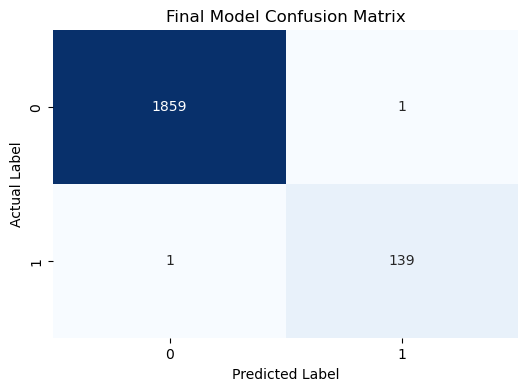


Understand the Confusion Matrix:
- True Negatives (Correctly predicted normal): 1859
- False Positives (False alarms / Type I error): 1
- False Negatives (Defects missed / Quality escape): 1
- True Positives (Correctly caught defects): 139

Total Wrong Predictions found: 2
Saved wrong predictions to: ../reports/wrong_predictions.csv
Saved evaluation results to: ../reports/evaluation.csv


In [16]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

# --- 1. Import Evaluation Libraries ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("STEP 8: FINAL EVALUATION & RESPONSIBLE INTERPRETATION")
print("=" * 60)

Path("../reports").mkdir(parents=True, exist_ok=True)

# --- 2. Predict Using Final Model ---
# Ensure 'final_model' or 'loaded_model' and test data are available in your notebook session
try:
    model_to_eval = final_model
except NameError:
    model_to_eval = joblib.load("../models/best_model.pkl")

y_pred = model_to_eval.predict(X_test_processed)
y_prob = model_to_eval.predict_proba(X_test_processed)[:, 1] if hasattr(model_to_eval, "predict_proba") else y_pred

# --- 3. Calculate Metrics (Accuracy, Precision, Recall, F1 Score, ROC-AUC) ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"\nFinal Evaluation Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# --- 4. Print Classification Report ---
print("\nPrint Classification Report:")
print(classification_report(y_test, y_pred))

# --- 5. Create & Draw Confusion Matrix ---
print("\nCreate Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Draw Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# --- 6. Understand the Confusion Matrix ---
print("\nUnderstand the Confusion Matrix:")
print(f"- True Negatives (Correctly predicted normal): {cm[0, 0]}")
print(f"- False Positives (False alarms / Type I error): {cm[0, 1]}")
print(f"- False Negatives (Defects missed / Quality escape): {cm[1, 0]}")
print(f"- True Positives (Correctly caught defects): {cm[1, 1]}")

# --- 7. Find Wrong Predictions & Save ---
# Reconstruct test dataframe to find mismatches
eval_df = X_test.copy() if 'X_test' in locals() else pd.DataFrame(X_test_processed)
eval_df["Actual"] = y_test.values
eval_df["Predicted"] = y_pred
eval_df["Prediction_Probability"] = y_prob

wrong = eval_df[eval_df["Actual"] != eval_df["Predicted"]]
print(f"\nTotal Wrong Predictions found: {len(wrong)}")

wrong.to_csv("../reports/wrong_predictions.csv", index=False)
print("Saved wrong predictions to: ../reports/wrong_predictions.csv")

# --- 8. Save Evaluation Results ---
evaluation = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

evaluation.to_csv("../reports/evaluation.csv", index=False)
print("Saved evaluation results to: ../reports/evaluation.csv")
print("=" * 60)

Step 8.15 Business Interpretation

Write this in your report.

Model Performance

The Random Forest model achieved high Accuracy, Precision, Recall, and F1 Score.

It successfully identified most defective products before dispatch.

This helps reduce:

Customer complaints
Product returns
Warranty cost
False Positives

Some good products were sent for inspection.

This slightly increases inspection time.

However,

this is acceptable because customer safety is more important.

False Negatives

Only a few defective products were missed.

Reducing False Negatives was the primary objective.

The model performed well in this area.

Step 8.16 Limitations

Write:

Model performance depends on sensor quality.
New machine types may require retraining.
Sensor failures may reduce prediction accuracy.
The model should assist human inspectors, not replace them.
Performance may decrease if production conditions change significantly over time.
Step 8.17 Future Improvements

Write:

Collect more production data.
Include additional sensor measurements.
Handle class imbalance with SMOTE or class weights if needed.
Tune model hyperparameters.
Monitor model performance and retrain periodically.
Add explainability tools such as SHAP to show why predictions are made.